# Pandas Data Cleaning & Analysis Project

## Project Overview
You have a real-world e-commerce transaction dataset with multiple data quality issues. Your task is to clean, transform, and analyze this messy data using pandas.

---

## Dataset Issues to Identify & Fix

The dataset (`student_sales_data.csv`) contains the following real-world problems:

### Data Quality Issues:
1. **Missing Values** - Some columns have NaN or empty values
2. **Inconsistent Data Types** - Some numeric columns may be stored as strings
3. **Duplicate Records** - Same customer making similar purchases (possibly duplicates)
4. **Inconsistent Formatting** - Customer names have mixed case (UPPERCASE, lowercase, Title Case)
5. **Invalid Data** - Negative amounts, zero quantities with prices
6. **Spelling Variations** - Same customer with different email addresses
7. **Outliers** - Unusual discount percentages or invalid negative transactions

---

## Tasks to Perform

### **Phase 1: Data Loading & Exploration**

In [1]:
# 1. Load the CSV file into a pandas DataFrame

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
sales_data=pd.read_csv(r"C:\Users\HP\Downloads\sales_data (1).csv")
sales_data

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,Unnamed: 14
0,TRX001,C001,John Smith,john@email.com,1/15/2024,Electronics,Laptop,1,999.99,999.99,Credit Card,USA,28,0,NaN
1,TRX002,C002,Sarah Johnson,sarah.johnson@mail.com,1/16/2024,Books,Python Guide,3,29.99,89.97,PayPal,Canada,35,10,NaN
2,TRX003,C003,MIKE WILLIAMS,mike@yahoo.com,1/16/2024,Electronics,USB Cable,10,5.99,NaN,Debit Card,USA,40,5,NaN
3,TRX004,C001,John Smith,john.smith@email.com,1/17/2024,Clothing,T-Shirt,2,19.99,39.98,Credit Card,USA,28,0,NaN
4,TRX005,C004,emily chen,emily_c@email.com,1/18/2024,Books,Data Science 101,1,45.00,45.00,Credit Card,UK,42,15,NaN
5,TRX006,C005,Robert Brown,robert@email.com,1/19/2024,Electronics,Monitor,1,349.99,NaN,PayPal,USA,51,10,NaN
6,TRX007,C002,Sarah Johnson,sarah@email.com,1/20/2024,Clothing,Jeans,1,79.99,79.99,Credit Card,Canada,35,20,NaN
7,TRX008,C006,Jessica Martinez,j.martinez@email.com,1/21/2024,Home,Coffee Maker,1,89.99,89.99,Debit Card,USA,29,0,NaN
8,TRX009,C007,David Lee,david.lee@hotmail.com,1/22/2024,Electronics,Headphones,2,149.99,299.98,Credit Card,USA,33,0,NaN
9,TRX010,C003,Mike Williams,mike.williams@email.com,1/23/2024,Books,The Art of Code,1,55.00,55.00,PayPal,USA,34,0,NaN


In [4]:
# . Display basic info:

In [5]:
# - Shape (rows, columns)
sales_data.shape

(30, 15)

In [6]:
# - Data types
sales_data.dtypes

transaction_id       object
customer_id          object
customer_name        object
email                object
purchase_date        object
product_category     object
product_name         object
quantity              int64
unit_price          float64
total_amount        float64
payment_method       object
shipping_country     object
customer_age          int64
discount_percent      int64
Unnamed: 14         float64
dtype: object

In [7]:
# - First and last few rows
sales_data.head()

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,Unnamed: 14
0,TRX001,C001,John Smith,john@email.com,1/15/2024,Electronics,Laptop,1,999.99,999.99,Credit Card,USA,28,0,NaN
1,TRX002,C002,Sarah Johnson,sarah.johnson@mail.com,1/16/2024,Books,Python Guide,3,29.99,89.97,PayPal,Canada,35,10,NaN
2,TRX003,C003,MIKE WILLIAMS,mike@yahoo.com,1/16/2024,Electronics,USB Cable,10,5.99,NaN,Debit Card,USA,40,5,NaN
3,TRX004,C001,John Smith,john.smith@email.com,1/17/2024,Clothing,T-Shirt,2,19.99,39.98,Credit Card,USA,28,0,NaN
4,TRX005,C004,emily chen,emily_c@email.com,1/18/2024,Books,Data Science 101,1,45.00,45.00,Credit Card,UK,42,15,NaN


In [8]:
sales_data.tail()

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,Unnamed: 14
25,TRX026,C021,Matthew Thomas,matthew.t@email.com,2/8/2024,Electronics,Monitor,1,349.99,349.99,Credit Card,USA,35,5,NaN
26,TRX027,C022,Olivia Jackson,olivia.j@email.com,2/9/2024,Clothing,Pants,2,69.99,139.98,Debit Card,Canada,31,15,NaN
27,TRX028,C023,Christopher White,christopher@email.com,2/10/2024,Home,Air Fryer,1,159.99,159.99,Credit Card,USA,44,0,NaN
28,TRX029,C024,Isabella Harris,isabella.h@email.com,2/11/2024,Books,Python Advanced,1,59.99,59.99,PayPal,USA,26,0,NaN
29,TRX030,C025,Benjamin Martin,b.martin@email.com,2/12/2024,Electronics,Laptop,1,1299.99,-1299.99,Credit Card,USA,52,40,NaN


In [9]:
# - Summary statistics
sales_data.describe()

,quantity,unit_price,total_amount,customer_age,discount_percent,Unnamed: 14
count,30.000000,30.000000,28.000000,30.000000,30.000000,1.0
mean,1.833333,180.858000,109.981786,36.533333,8.233333,5.0
std,1.801978,284.858912,334.329231,8.186336,10.060792,NaN
min,1.000000,5.990000,-1299.990000,26.000000,0.000000,5.0
25%,1.000000,46.247500,58.742500,29.500000,0.000000,5.0
50%,1.000000,74.990000,89.990000,35.000000,5.000000,5.0
75%,2.000000,157.490000,164.985000,41.750000,14.250000,5.0
max,10.000000,1299.990000,999.990000,55.000000,40.000000,5.0


In [10]:
#    - Missing value counts
sales_data.isnull().value_counts().sum()

np.int64(30)

In [11]:
sales_data.columns

Index(['transaction_id', 'customer_id', 'customer_name', 'email',
       'purchase_date', 'product_category', 'product_name', 'quantity',
       'unit_price', 'total_amount', 'payment_method', 'shipping_country',
       'customer_age', 'discount_percent', 'Unnamed: 14'],
      dtype='object')

In [12]:
# ### **Phase 2: Data Cleaning**

In [13]:
# 4. **Handle Missing Values:**

In [14]:
# - Fill missing `quantity` values with 1 (default order quantity)
sales_data["quantity"] = sales_data["quantity"].fillna(1)
sales_data

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,Unnamed: 14
0,TRX001,C001,John Smith,john@email.com,1/15/2024,Electronics,Laptop,1,999.99,999.99,Credit Card,USA,28,0,NaN
1,TRX002,C002,Sarah Johnson,sarah.johnson@mail.com,1/16/2024,Books,Python Guide,3,29.99,89.97,PayPal,Canada,35,10,NaN
2,TRX003,C003,MIKE WILLIAMS,mike@yahoo.com,1/16/2024,Electronics,USB Cable,10,5.99,NaN,Debit Card,USA,40,5,NaN
3,TRX004,C001,John Smith,john.smith@email.com,1/17/2024,Clothing,T-Shirt,2,19.99,39.98,Credit Card,USA,28,0,NaN
4,TRX005,C004,emily chen,emily_c@email.com,1/18/2024,Books,Data Science 101,1,45.00,45.00,Credit Card,UK,42,15,NaN
5,TRX006,C005,Robert Brown,robert@email.com,1/19/2024,Electronics,Monitor,1,349.99,NaN,PayPal,USA,51,10,NaN
6,TRX007,C002,Sarah Johnson,sarah@email.com,1/20/2024,Clothing,Jeans,1,79.99,79.99,Credit Card,Canada,35,20,NaN
7,TRX008,C006,Jessica Martinez,j.martinez@email.com,1/21/2024,Home,Coffee Maker,1,89.99,89.99,Debit Card,USA,29,0,NaN
8,TRX009,C007,David Lee,david.lee@hotmail.com,1/22/2024,Electronics,Headphones,2,149.99,299.98,Credit Card,USA,33,0,NaN
9,TRX010,C003,Mike Williams,mike.williams@email.com,1/23/2024,Books,The Art of Code,1,55.00,55.00,PayPal,USA,34,0,NaN


In [15]:
#    - Fill missing `total_amount` by calculating: `quantity × unit_price`
sales_data["total_amount"]=sales_data["quantity"]*sales_data["unit_price"]
sales_data["total_amount"]=sales_data["total_amount"].fillna(sales_data["total_amount"])
sales_data

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,Unnamed: 14
0,TRX001,C001,John Smith,john@email.com,1/15/2024,Electronics,Laptop,1,999.99,999.99,Credit Card,USA,28,0,NaN
1,TRX002,C002,Sarah Johnson,sarah.johnson@mail.com,1/16/2024,Books,Python Guide,3,29.99,89.97,PayPal,Canada,35,10,NaN
2,TRX003,C003,MIKE WILLIAMS,mike@yahoo.com,1/16/2024,Electronics,USB Cable,10,5.99,59.90,Debit Card,USA,40,5,NaN
3,TRX004,C001,John Smith,john.smith@email.com,1/17/2024,Clothing,T-Shirt,2,19.99,39.98,Credit Card,USA,28,0,NaN
4,TRX005,C004,emily chen,emily_c@email.com,1/18/2024,Books,Data Science 101,1,45.00,45.00,Credit Card,UK,42,15,NaN
5,TRX006,C005,Robert Brown,robert@email.com,1/19/2024,Electronics,Monitor,1,349.99,349.99,PayPal,USA,51,10,NaN
6,TRX007,C002,Sarah Johnson,sarah@email.com,1/20/2024,Clothing,Jeans,1,79.99,79.99,Credit Card,Canada,35,20,NaN
7,TRX008,C006,Jessica Martinez,j.martinez@email.com,1/21/2024,Home,Coffee Maker,1,89.99,89.99,Debit Card,USA,29,0,NaN
8,TRX009,C007,David Lee,david.lee@hotmail.com,1/22/2024,Electronics,Headphones,2,149.99,299.98,Credit Card,USA,33,0,NaN
9,TRX010,C003,Mike Williams,mike.williams@email.com,1/23/2024,Books,The Art of Code,1,55.00,55.00,PayPal,USA,34,0,NaN


In [16]:
# - Fill missing `customer_age` with the median age
sales_data["customer_age"]=sales_data["customer_age"].fillna(sales_data["customer_age"].median())
sales_data

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,Unnamed: 14
0,TRX001,C001,John Smith,john@email.com,1/15/2024,Electronics,Laptop,1,999.99,999.99,Credit Card,USA,28,0,NaN
1,TRX002,C002,Sarah Johnson,sarah.johnson@mail.com,1/16/2024,Books,Python Guide,3,29.99,89.97,PayPal,Canada,35,10,NaN
2,TRX003,C003,MIKE WILLIAMS,mike@yahoo.com,1/16/2024,Electronics,USB Cable,10,5.99,59.90,Debit Card,USA,40,5,NaN
3,TRX004,C001,John Smith,john.smith@email.com,1/17/2024,Clothing,T-Shirt,2,19.99,39.98,Credit Card,USA,28,0,NaN
4,TRX005,C004,emily chen,emily_c@email.com,1/18/2024,Books,Data Science 101,1,45.00,45.00,Credit Card,UK,42,15,NaN
5,TRX006,C005,Robert Brown,robert@email.com,1/19/2024,Electronics,Monitor,1,349.99,349.99,PayPal,USA,51,10,NaN
6,TRX007,C002,Sarah Johnson,sarah@email.com,1/20/2024,Clothing,Jeans,1,79.99,79.99,Credit Card,Canada,35,20,NaN
7,TRX008,C006,Jessica Martinez,j.martinez@email.com,1/21/2024,Home,Coffee Maker,1,89.99,89.99,Debit Card,USA,29,0,NaN
8,TRX009,C007,David Lee,david.lee@hotmail.com,1/22/2024,Electronics,Headphones,2,149.99,299.98,Credit Card,USA,33,0,NaN
9,TRX010,C003,Mike Williams,mike.williams@email.com,1/23/2024,Books,The Art of Code,1,55.00,55.00,PayPal,USA,34,0,NaN


In [17]:
# - Drop rows where critical information is completely missing
sales_data = sales_data.dropna(subset=[
    "customer_id",
    "purchase_date",
    "product_name",
    "total_amount"
])
sales_data

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,Unnamed: 14
0,TRX001,C001,John Smith,john@email.com,1/15/2024,Electronics,Laptop,1,999.99,999.99,Credit Card,USA,28,0,NaN
1,TRX002,C002,Sarah Johnson,sarah.johnson@mail.com,1/16/2024,Books,Python Guide,3,29.99,89.97,PayPal,Canada,35,10,NaN
2,TRX003,C003,MIKE WILLIAMS,mike@yahoo.com,1/16/2024,Electronics,USB Cable,10,5.99,59.90,Debit Card,USA,40,5,NaN
3,TRX004,C001,John Smith,john.smith@email.com,1/17/2024,Clothing,T-Shirt,2,19.99,39.98,Credit Card,USA,28,0,NaN
4,TRX005,C004,emily chen,emily_c@email.com,1/18/2024,Books,Data Science 101,1,45.00,45.00,Credit Card,UK,42,15,NaN
5,TRX006,C005,Robert Brown,robert@email.com,1/19/2024,Electronics,Monitor,1,349.99,349.99,PayPal,USA,51,10,NaN
6,TRX007,C002,Sarah Johnson,sarah@email.com,1/20/2024,Clothing,Jeans,1,79.99,79.99,Credit Card,Canada,35,20,NaN
7,TRX008,C006,Jessica Martinez,j.martinez@email.com,1/21/2024,Home,Coffee Maker,1,89.99,89.99,Debit Card,USA,29,0,NaN
8,TRX009,C007,David Lee,david.lee@hotmail.com,1/22/2024,Electronics,Headphones,2,149.99,299.98,Credit Card,USA,33,0,NaN
9,TRX010,C003,Mike Williams,mike.williams@email.com,1/23/2024,Books,The Art of Code,1,55.00,55.00,PayPal,USA,34,0,NaN


In [18]:
# 5. **Standardize Text Data:**

In [19]:
# - Convert all customer names to Title Case (consistent formatting)
sales_data["customer_name"] = sales_data["customer_name"].astype(str).str.title()
sales_data

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,Unnamed: 14
0,TRX001,C001,John Smith,john@email.com,1/15/2024,Electronics,Laptop,1,999.99,999.99,Credit Card,USA,28,0,NaN
1,TRX002,C002,Sarah Johnson,sarah.johnson@mail.com,1/16/2024,Books,Python Guide,3,29.99,89.97,PayPal,Canada,35,10,NaN
2,TRX003,C003,Mike Williams,mike@yahoo.com,1/16/2024,Electronics,USB Cable,10,5.99,59.90,Debit Card,USA,40,5,NaN
3,TRX004,C001,John Smith,john.smith@email.com,1/17/2024,Clothing,T-Shirt,2,19.99,39.98,Credit Card,USA,28,0,NaN
4,TRX005,C004,Emily Chen,emily_c@email.com,1/18/2024,Books,Data Science 101,1,45.00,45.00,Credit Card,UK,42,15,NaN
5,TRX006,C005,Robert Brown,robert@email.com,1/19/2024,Electronics,Monitor,1,349.99,349.99,PayPal,USA,51,10,NaN
6,TRX007,C002,Sarah Johnson,sarah@email.com,1/20/2024,Clothing,Jeans,1,79.99,79.99,Credit Card,Canada,35,20,NaN
7,TRX008,C006,Jessica Martinez,j.martinez@email.com,1/21/2024,Home,Coffee Maker,1,89.99,89.99,Debit Card,USA,29,0,NaN
8,TRX009,C007,David Lee,david.lee@hotmail.com,1/22/2024,Electronics,Headphones,2,149.99,299.98,Credit Card,USA,33,0,NaN
9,TRX010,C003,Mike Williams,mike.williams@email.com,1/23/2024,Books,The Art of Code,1,55.00,55.00,PayPal,USA,34,0,NaN


In [20]:
# - Convert emails to lowercase
sales_data["email"]=sales_data["email"].str.lower()
sales_data

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,Unnamed: 14
0,TRX001,C001,John Smith,john@email.com,1/15/2024,Electronics,Laptop,1,999.99,999.99,Credit Card,USA,28,0,NaN
1,TRX002,C002,Sarah Johnson,sarah.johnson@mail.com,1/16/2024,Books,Python Guide,3,29.99,89.97,PayPal,Canada,35,10,NaN
2,TRX003,C003,Mike Williams,mike@yahoo.com,1/16/2024,Electronics,USB Cable,10,5.99,59.90,Debit Card,USA,40,5,NaN
3,TRX004,C001,John Smith,john.smith@email.com,1/17/2024,Clothing,T-Shirt,2,19.99,39.98,Credit Card,USA,28,0,NaN
4,TRX005,C004,Emily Chen,emily_c@email.com,1/18/2024,Books,Data Science 101,1,45.00,45.00,Credit Card,UK,42,15,NaN
5,TRX006,C005,Robert Brown,robert@email.com,1/19/2024,Electronics,Monitor,1,349.99,349.99,PayPal,USA,51,10,NaN
6,TRX007,C002,Sarah Johnson,sarah@email.com,1/20/2024,Clothing,Jeans,1,79.99,79.99,Credit Card,Canada,35,20,NaN
7,TRX008,C006,Jessica Martinez,j.martinez@email.com,1/21/2024,Home,Coffee Maker,1,89.99,89.99,Debit Card,USA,29,0,NaN
8,TRX009,C007,David Lee,david.lee@hotmail.com,1/22/2024,Electronics,Headphones,2,149.99,299.98,Credit Card,USA,33,0,NaN
9,TRX010,C003,Mike Williams,mike.williams@email.com,1/23/2024,Books,The Art of Code,1,55.00,55.00,PayPal,USA,34,0,NaN


In [21]:
# - Trim whitespace from all string columns
cols=["customer_name", "email", "product_name"]
sales_data[cols]=sales_data[cols].apply(lambda x:x.str.strip())
sales_data

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,Unnamed: 14
0,TRX001,C001,John Smith,john@email.com,1/15/2024,Electronics,Laptop,1,999.99,999.99,Credit Card,USA,28,0,NaN
1,TRX002,C002,Sarah Johnson,sarah.johnson@mail.com,1/16/2024,Books,Python Guide,3,29.99,89.97,PayPal,Canada,35,10,NaN
2,TRX003,C003,Mike Williams,mike@yahoo.com,1/16/2024,Electronics,USB Cable,10,5.99,59.90,Debit Card,USA,40,5,NaN
3,TRX004,C001,John Smith,john.smith@email.com,1/17/2024,Clothing,T-Shirt,2,19.99,39.98,Credit Card,USA,28,0,NaN
4,TRX005,C004,Emily Chen,emily_c@email.com,1/18/2024,Books,Data Science 101,1,45.00,45.00,Credit Card,UK,42,15,NaN
5,TRX006,C005,Robert Brown,robert@email.com,1/19/2024,Electronics,Monitor,1,349.99,349.99,PayPal,USA,51,10,NaN
6,TRX007,C002,Sarah Johnson,sarah@email.com,1/20/2024,Clothing,Jeans,1,79.99,79.99,Credit Card,Canada,35,20,NaN
7,TRX008,C006,Jessica Martinez,j.martinez@email.com,1/21/2024,Home,Coffee Maker,1,89.99,89.99,Debit Card,USA,29,0,NaN
8,TRX009,C007,David Lee,david.lee@hotmail.com,1/22/2024,Electronics,Headphones,2,149.99,299.98,Credit Card,USA,33,0,NaN
9,TRX010,C003,Mike Williams,mike.williams@email.com,1/23/2024,Books,The Art of Code,1,55.00,55.00,PayPal,USA,34,0,NaN


In [22]:
# 6. **Fix Data Types:**

In [23]:
# - Ensure all numeric columns (quantity, unit_price, total_amount, discount_percent, customer_age) are numeric
cols=["quantity", "unit_price", "total_amount", "discount_percent", "customer_age"]
sales_data[cols]=sales_data[cols].apply(pd.to_numeric,errors="coerce")
sales_data

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,Unnamed: 14
0,TRX001,C001,John Smith,john@email.com,1/15/2024,Electronics,Laptop,1,999.99,999.99,Credit Card,USA,28,0,NaN
1,TRX002,C002,Sarah Johnson,sarah.johnson@mail.com,1/16/2024,Books,Python Guide,3,29.99,89.97,PayPal,Canada,35,10,NaN
2,TRX003,C003,Mike Williams,mike@yahoo.com,1/16/2024,Electronics,USB Cable,10,5.99,59.90,Debit Card,USA,40,5,NaN
3,TRX004,C001,John Smith,john.smith@email.com,1/17/2024,Clothing,T-Shirt,2,19.99,39.98,Credit Card,USA,28,0,NaN
4,TRX005,C004,Emily Chen,emily_c@email.com,1/18/2024,Books,Data Science 101,1,45.00,45.00,Credit Card,UK,42,15,NaN
5,TRX006,C005,Robert Brown,robert@email.com,1/19/2024,Electronics,Monitor,1,349.99,349.99,PayPal,USA,51,10,NaN
6,TRX007,C002,Sarah Johnson,sarah@email.com,1/20/2024,Clothing,Jeans,1,79.99,79.99,Credit Card,Canada,35,20,NaN
7,TRX008,C006,Jessica Martinez,j.martinez@email.com,1/21/2024,Home,Coffee Maker,1,89.99,89.99,Debit Card,USA,29,0,NaN
8,TRX009,C007,David Lee,david.lee@hotmail.com,1/22/2024,Electronics,Headphones,2,149.99,299.98,Credit Card,USA,33,0,NaN
9,TRX010,C003,Mike Williams,mike.williams@email.com,1/23/2024,Books,The Art of Code,1,55.00,55.00,PayPal,USA,34,0,NaN


In [24]:
# - Convert purchase_date to datetime format
sales_data["purchase_date"]=pd.to_datetime(sales_data["purchase_date"])
sales_data

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,Unnamed: 14
0,TRX001,C001,John Smith,john@email.com,2024-01-15,Electronics,Laptop,1,999.99,999.99,Credit Card,USA,28,0,NaN
1,TRX002,C002,Sarah Johnson,sarah.johnson@mail.com,2024-01-16,Books,Python Guide,3,29.99,89.97,PayPal,Canada,35,10,NaN
2,TRX003,C003,Mike Williams,mike@yahoo.com,2024-01-16,Electronics,USB Cable,10,5.99,59.90,Debit Card,USA,40,5,NaN
3,TRX004,C001,John Smith,john.smith@email.com,2024-01-17,Clothing,T-Shirt,2,19.99,39.98,Credit Card,USA,28,0,NaN
4,TRX005,C004,Emily Chen,emily_c@email.com,2024-01-18,Books,Data Science 101,1,45.00,45.00,Credit Card,UK,42,15,NaN
5,TRX006,C005,Robert Brown,robert@email.com,2024-01-19,Electronics,Monitor,1,349.99,349.99,PayPal,USA,51,10,NaN
6,TRX007,C002,Sarah Johnson,sarah@email.com,2024-01-20,Clothing,Jeans,1,79.99,79.99,Credit Card,Canada,35,20,NaN
7,TRX008,C006,Jessica Martinez,j.martinez@email.com,2024-01-21,Home,Coffee Maker,1,89.99,89.99,Debit Card,USA,29,0,NaN
8,TRX009,C007,David Lee,david.lee@hotmail.com,2024-01-22,Electronics,Headphones,2,149.99,299.98,Credit Card,USA,33,0,NaN
9,TRX010,C003,Mike Williams,mike.williams@email.com,2024-01-23,Books,The Art of Code,1,55.00,55.00,PayPal,USA,34,0,NaN


In [25]:
# - Verify payment_method and product_category are strings
sales_data[["payment_method","product_category"]].dtypes

payment_method      object
product_category    object
dtype: object

In [26]:
# 7. **Remove/Fix Duplicates:**

In [27]:
# - Identify duplicate transactions (same transaction_id)
sales_data[sales_data["transaction_id"].duplicated()]
sales_data["transaction_id"].duplicated().sum()

np.int64(0)

In [28]:
# - Identify duplicate customers with slightly different names/emails
sales_data["customer_name"]=sales_data["customer_name"].str.strip().str.lower()
sales_data
sales_data["email"]=sales_data["email"].str.strip().str.lower()
sales_data
sales_data[sales_data.duplicated(subset=["customer_name","email"],keep=False)]

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,Unnamed: 14


In [29]:
#    - Keep only one record per duplicate (based on most recent date)

In [34]:
# 8. **Fix Invalid Data:**
   # - Remove or fix rows with negative total_amount
   # - Ensure discount_percent is between 0 and 100
   # - Verify quantity is positive
   # - Fix records where unit_price doesn't match total_amount / quantity

In [35]:
# ### **Phase 3: Feature Engineering**

In [36]:
# 9. **Create New Columns:**

In [37]:
#    - `net_amount`: total_amount after applying discount
sales_data["net_amount"]=sales_data["total_amount"]*(30/100)
sales_data

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,Unnamed: 14,net_amount
0,TRX001,C001,john smith,john@email.com,2024-01-15,Electronics,Laptop,1,999.99,999.99,Credit Card,USA,28,0,NaN,299.997
1,TRX002,C002,sarah johnson,sarah.johnson@mail.com,2024-01-16,Books,Python Guide,3,29.99,89.97,PayPal,Canada,35,10,NaN,26.991
2,TRX003,C003,mike williams,mike@yahoo.com,2024-01-16,Electronics,USB Cable,10,5.99,59.90,Debit Card,USA,40,5,NaN,17.970
3,TRX004,C001,john smith,john.smith@email.com,2024-01-17,Clothing,T-Shirt,2,19.99,39.98,Credit Card,USA,28,0,NaN,11.994
4,TRX005,C004,emily chen,emily_c@email.com,2024-01-18,Books,Data Science 101,1,45.00,45.00,Credit Card,UK,42,15,NaN,13.500
5,TRX006,C005,robert brown,robert@email.com,2024-01-19,Electronics,Monitor,1,349.99,349.99,PayPal,USA,51,10,NaN,104.997
6,TRX007,C002,sarah johnson,sarah@email.com,2024-01-20,Clothing,Jeans,1,79.99,79.99,Credit Card,Canada,35,20,NaN,23.997
7,TRX008,C006,jessica martinez,j.martinez@email.com,2024-01-21,Home,Coffee Maker,1,89.99,89.99,Debit Card,USA,29,0,NaN,26.997
8,TRX009,C007,david lee,david.lee@hotmail.com,2024-01-22,Electronics,Headphones,2,149.99,299.98,Credit Card,USA,33,0,NaN,89.994
9,TRX010,C003,mike williams,mike.williams@email.com,2024-01-23,Books,The Art of Code,1,55.00,55.00,PayPal,USA,34,0,NaN,16.500


In [38]:
# - `year_month`: Extract year-month from purchase_date
sales_data["year_month"]=sales_data["purchase_date"].dt.to_period("M")
sales_data

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,Unnamed: 14,net_amount,year_month
0,TRX001,C001,john smith,john@email.com,2024-01-15,Electronics,Laptop,1,999.99,999.99,Credit Card,USA,28,0,NaN,299.997,2024-01
1,TRX002,C002,sarah johnson,sarah.johnson@mail.com,2024-01-16,Books,Python Guide,3,29.99,89.97,PayPal,Canada,35,10,NaN,26.991,2024-01
2,TRX003,C003,mike williams,mike@yahoo.com,2024-01-16,Electronics,USB Cable,10,5.99,59.90,Debit Card,USA,40,5,NaN,17.970,2024-01
3,TRX004,C001,john smith,john.smith@email.com,2024-01-17,Clothing,T-Shirt,2,19.99,39.98,Credit Card,USA,28,0,NaN,11.994,2024-01
4,TRX005,C004,emily chen,emily_c@email.com,2024-01-18,Books,Data Science 101,1,45.00,45.00,Credit Card,UK,42,15,NaN,13.500,2024-01
5,TRX006,C005,robert brown,robert@email.com,2024-01-19,Electronics,Monitor,1,349.99,349.99,PayPal,USA,51,10,NaN,104.997,2024-01
6,TRX007,C002,sarah johnson,sarah@email.com,2024-01-20,Clothing,Jeans,1,79.99,79.99,Credit Card,Canada,35,20,NaN,23.997,2024-01
7,TRX008,C006,jessica martinez,j.martinez@email.com,2024-01-21,Home,Coffee Maker,1,89.99,89.99,Debit Card,USA,29,0,NaN,26.997,2024-01
8,TRX009,C007,david lee,david.lee@hotmail.com,2024-01-22,Electronics,Headphones,2,149.99,299.98,Credit Card,USA,33,0,NaN,89.994,2024-01
9,TRX010,C003,mike williams,mike.williams@email.com,2024-01-23,Books,The Art of Code,1,55.00,55.00,PayPal,USA,34,0,NaN,16.500,2024-01


In [39]:
# - `customer_segment`: Categorize customers as:
     # - "High Value" if total spending > $500
     # - "Medium Value" if total spending $100-$500
     # - "Low Value" if total spending < $100

sales_data["customer_segment"]=sales_data["total_amount"].apply(lambda x:"high" if x>500 else("medium" if x>100 else "low"))
sales_data

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,Unnamed: 14,net_amount,year_month,customer_segment
0,TRX001,C001,john smith,john@email.com,2024-01-15,Electronics,Laptop,1,999.99,999.99,Credit Card,USA,28,0,NaN,299.997,2024-01,high
1,TRX002,C002,sarah johnson,sarah.johnson@mail.com,2024-01-16,Books,Python Guide,3,29.99,89.97,PayPal,Canada,35,10,NaN,26.991,2024-01,low
2,TRX003,C003,mike williams,mike@yahoo.com,2024-01-16,Electronics,USB Cable,10,5.99,59.90,Debit Card,USA,40,5,NaN,17.970,2024-01,low
3,TRX004,C001,john smith,john.smith@email.com,2024-01-17,Clothing,T-Shirt,2,19.99,39.98,Credit Card,USA,28,0,NaN,11.994,2024-01,low
4,TRX005,C004,emily chen,emily_c@email.com,2024-01-18,Books,Data Science 101,1,45.00,45.00,Credit Card,UK,42,15,NaN,13.500,2024-01,low
5,TRX006,C005,robert brown,robert@email.com,2024-01-19,Electronics,Monitor,1,349.99,349.99,PayPal,USA,51,10,NaN,104.997,2024-01,medium
6,TRX007,C002,sarah johnson,sarah@email.com,2024-01-20,Clothing,Jeans,1,79.99,79.99,Credit Card,Canada,35,20,NaN,23.997,2024-01,low
7,TRX008,C006,jessica martinez,j.martinez@email.com,2024-01-21,Home,Coffee Maker,1,89.99,89.99,Debit Card,USA,29,0,NaN,26.997,2024-01,low
8,TRX009,C007,david lee,david.lee@hotmail.com,2024-01-22,Electronics,Headphones,2,149.99,299.98,Credit Card,USA,33,0,NaN,89.994,2024-01,medium
9,TRX010,C003,mike williams,mike.williams@email.com,2024-01-23,Books,The Art of Code,1,55.00,55.00,PayPal,USA,34,0,NaN,16.500,2024-01,low


In [40]:
# 10. **Add Derived Features:**

In [41]:
#  - `discount_amount`: Calculate actual discount amount in dollars
sales_data["into_dollars"]=sales_data["net_amount"]/83
sales_data

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,Unnamed: 14,net_amount,year_month,customer_segment,into_dollars
0,TRX001,C001,john smith,john@email.com,2024-01-15,Electronics,Laptop,1,999.99,999.99,Credit Card,USA,28,0,NaN,299.997,2024-01,high,3.614422
1,TRX002,C002,sarah johnson,sarah.johnson@mail.com,2024-01-16,Books,Python Guide,3,29.99,89.97,PayPal,Canada,35,10,NaN,26.991,2024-01,low,0.325193
2,TRX003,C003,mike williams,mike@yahoo.com,2024-01-16,Electronics,USB Cable,10,5.99,59.90,Debit Card,USA,40,5,NaN,17.970,2024-01,low,0.216506
3,TRX004,C001,john smith,john.smith@email.com,2024-01-17,Clothing,T-Shirt,2,19.99,39.98,Credit Card,USA,28,0,NaN,11.994,2024-01,low,0.144506
4,TRX005,C004,emily chen,emily_c@email.com,2024-01-18,Books,Data Science 101,1,45.00,45.00,Credit Card,UK,42,15,NaN,13.500,2024-01,low,0.162651
5,TRX006,C005,robert brown,robert@email.com,2024-01-19,Electronics,Monitor,1,349.99,349.99,PayPal,USA,51,10,NaN,104.997,2024-01,medium,1.265024
6,TRX007,C002,sarah johnson,sarah@email.com,2024-01-20,Clothing,Jeans,1,79.99,79.99,Credit Card,Canada,35,20,NaN,23.997,2024-01,low,0.289120
7,TRX008,C006,jessica martinez,j.martinez@email.com,2024-01-21,Home,Coffee Maker,1,89.99,89.99,Debit Card,USA,29,0,NaN,26.997,2024-01,low,0.325265
8,TRX009,C007,david lee,david.lee@hotmail.com,2024-01-22,Electronics,Headphones,2,149.99,299.98,Credit Card,USA,33,0,NaN,89.994,2024-01,medium,1.084265
9,TRX010,C003,mike williams,mike.williams@email.com,2024-01-23,Books,The Art of Code,1,55.00,55.00,PayPal,USA,34,0,NaN,16.500,2024-01,low,0.198795


In [42]:
#  - `is_repeat_customer`: Boolean indicating if customer has multiple purchases
sales_data["is_repeat_customer"]=sales_data["customer_id"].map(sales_data["customer_id"].value_counts()>1)
sales_data

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,Unnamed: 14,net_amount,year_month,customer_segment,into_dollars,is_repeat_customer
0,TRX001,C001,john smith,john@email.com,2024-01-15,Electronics,Laptop,1,999.99,999.99,Credit Card,USA,28,0,NaN,299.997,2024-01,high,3.614422,True
1,TRX002,C002,sarah johnson,sarah.johnson@mail.com,2024-01-16,Books,Python Guide,3,29.99,89.97,PayPal,Canada,35,10,NaN,26.991,2024-01,low,0.325193,True
2,TRX003,C003,mike williams,mike@yahoo.com,2024-01-16,Electronics,USB Cable,10,5.99,59.90,Debit Card,USA,40,5,NaN,17.970,2024-01,low,0.216506,True
3,TRX004,C001,john smith,john.smith@email.com,2024-01-17,Clothing,T-Shirt,2,19.99,39.98,Credit Card,USA,28,0,NaN,11.994,2024-01,low,0.144506,True
4,TRX005,C004,emily chen,emily_c@email.com,2024-01-18,Books,Data Science 101,1,45.00,45.00,Credit Card,UK,42,15,NaN,13.500,2024-01,low,0.162651,False
5,TRX006,C005,robert brown,robert@email.com,2024-01-19,Electronics,Monitor,1,349.99,349.99,PayPal,USA,51,10,NaN,104.997,2024-01,medium,1.265024,False
6,TRX007,C002,sarah johnson,sarah@email.com,2024-01-20,Clothing,Jeans,1,79.99,79.99,Credit Card,Canada,35,20,NaN,23.997,2024-01,low,0.289120,True
7,TRX008,C006,jessica martinez,j.martinez@email.com,2024-01-21,Home,Coffee Maker,1,89.99,89.99,Debit Card,USA,29,0,NaN,26.997,2024-01,low,0.325265,False
8,TRX009,C007,david lee,david.lee@hotmail.com,2024-01-22,Electronics,Headphones,2,149.99,299.98,Credit Card,USA,33,0,NaN,89.994,2024-01,medium,1.084265,False
9,TRX010,C003,mike williams,mike.williams@email.com,2024-01-23,Books,The Art of Code,1,55.00,55.00,PayPal,USA,34,0,NaN,16.500,2024-01,low,0.198795,True


In [43]:
#  - `purchase_quarter`: Extract quarter from purchase_date
sales_data["purchase_quarter"]=sales_data["purchase_date"].dt.quarter
sales_data

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,...,shipping_country,customer_age,discount_percent,Unnamed: 14,net_amount,year_month,customer_segment,into_dollars,is_repeat_customer,purchase_quarter
0,TRX001,C001,john smith,john@email.com,2024-01-15,Electronics,Laptop,1,999.99,999.99,...,USA,28,0,NaN,299.997,2024-01,high,3.614422,True,1
1,TRX002,C002,sarah johnson,sarah.johnson@mail.com,2024-01-16,Books,Python Guide,3,29.99,89.97,...,Canada,35,10,NaN,26.991,2024-01,low,0.325193,True,1
2,TRX003,C003,mike williams,mike@yahoo.com,2024-01-16,Electronics,USB Cable,10,5.99,59.90,...,USA,40,5,NaN,17.970,2024-01,low,0.216506,True,1
3,TRX004,C001,john smith,john.smith@email.com,2024-01-17,Clothing,T-Shirt,2,19.99,39.98,...,USA,28,0,NaN,11.994,2024-01,low,0.144506,True,1
4,TRX005,C004,emily chen,emily_c@email.com,2024-01-18,Books,Data Science 101,1,45.00,45.00,...,UK,42,15,NaN,13.500,2024-01,low,0.162651,False,1
5,TRX006,C005,robert brown,robert@email.com,2024-01-19,Electronics,Monitor,1,349.99,349.99,...,USA,51,10,NaN,104.997,2024-01,medium,1.265024,False,1
6,TRX007,C002,sarah johnson,sarah@email.com,2024-01-20,Clothing,Jeans,1,79.99,79.99,...,Canada,35,20,NaN,23.997,2024-01,low,0.289120,True,1
7,TRX008,C006,jessica martinez,j.martinez@email.com,2024-01-21,Home,Coffee Maker,1,89.99,89.99,...,USA,29,0,NaN,26.997,2024-01,low,0.325265,False,1
8,TRX009,C007,david lee,david.lee@hotmail.com,2024-01-22,Electronics,Headphones,2,149.99,299.98,...,USA,33,0,NaN,89.994,2024-01,medium,1.084265,False,1
9,TRX010,C003,mike williams,mike.williams@email.com,2024-01-23,Books,The Art of Code,1,55.00,55.00,...,USA,34,0,NaN,16.500,2024-01,low,0.198795,True,1


In [44]:
# ### **Phase 4: Data Analysis & Insights**

In [45]:
# 11. **Descriptive Statistics:**

In [46]:
# - Average transaction amount
sales_data["total_amount"].mean()

np.float64(215.64999999999995)

In [47]:
# - Median discount percentage
sales_data["net_amount"].median()

34.497

In [48]:
#  - Most popular product category
sales_data["product_category"].sort_values(ascending=False).head(1)
sales_data["product_category"].max()

'Home'

In [49]:
# - Most common payment method
sales_data["payment_method"].max()

'PayPal'

In [50]:
# - Customer age statistics
sales_data["customer_age"].describe()

count    30.000000
mean     36.533333
std       8.186336
min      26.000000
25%      29.500000
50%      35.000000
75%      41.750000
max      55.000000
Name: customer_age, dtype: float64

In [51]:
# 12. **Customer Analysis:**

In [52]:
# - Total number of unique customers
sales_data["customer_id"].nunique()

25

In [53]:
# - Customer spending by segment
sales_data.groupby("customer_id")["total_amount"].sum()

customer_id
C001    1039.97
C002     354.96
C003     114.90
C004      45.00
C005     349.99
C006      89.99
C007     299.98
C008     179.97
C009      99.99
C010     129.99
C011     349.99
C012     599.98
C013      39.99
C014      69.98
C015     149.95
C016      89.99
C017      74.97
C018     199.99
C019     129.99
C020      49.99
C021     349.99
C022     139.98
C023     159.99
C024      59.99
C025    1299.99
Name: total_amount, dtype: float64

In [54]:
# - Repeat customers (customers with 2+ transactions)
(sales_data["customer_id"].value_counts() >= 2).sum()

np.int64(3)

In [55]:
# - Top 5 customers by total spending
sales_data["total_amount"].sort_values(ascending=False).head()

29    1299.99
0      999.99
15     599.98
25     349.99
14     349.99
Name: total_amount, dtype: float64

In [56]:
# 13. **Product & Category Analysis:**

In [57]:
#  - Total sales by product category
sales_data.groupby("product_category")["total_amount"].sum()

product_category
Books           524.94
Clothing       1259.88
Electronics    4034.74
Home            649.94
Name: total_amount, dtype: float64

In [58]:
# - Average order value by category
sales_data.groupby("product_category")["total_amount"].mean()

product_category
Books           65.617500
Clothing       179.982857
Electronics    403.474000
Home           129.988000
Name: total_amount, dtype: float64

In [59]:
# - Most sold products (by quantity and by revenue)
sales_data.groupby("product_name")["quantity"].sum().sort_values(ascending=False).head()

product_name
USB Cable       10
Mouse            5
Dress            3
Monitor          3
Python Guide     3
Name: quantity, dtype: int64

In [60]:
sales_data.groupby("product_name")["total_amount"].sum().sort_values(ascending=False).head()

product_name
Laptop        2299.98
Monitor       1049.97
Jacket         599.98
Headphones     299.98
Microwave      199.99
Name: total_amount, dtype: float64

In [61]:
# - Category preferences by customer age group

In [62]:
# 14. **Geographic Analysis:**

In [63]:
# sales by shipping country
sales_data.groupby('shipping_country')["total_amount"].sum()

shipping_country
Canada      494.94
France      179.97
Germany      99.99
UK           45.00
USA        5649.60
Name: total_amount, dtype: float64

In [64]:
# - Average transaction value by country
sales_data.groupby('shipping_country')["total_amount"].mean()

shipping_country
Canada      98.988
France     179.970
Germany     99.990
UK          45.000
USA        256.800
Name: total_amount, dtype: float64

In [65]:
#  - Top countries by number of transactions
sales_data.groupby('shipping_country')["transaction_id"].count().sort_values(ascending=False).head()

shipping_country
USA        22
Canada      5
France      1
Germany     1
UK          1
Name: transaction_id, dtype: int64

In [66]:
# 15. **Time Series Analysis:**

In [67]:
month=sales_data["purchase_date"].dt.month_name()
# - Sales trend by month
sales_trend=sales_data.groupby(month)["total_amount"].sum()
sales_trend

purchase_date
February    2759.82
January     3709.68
Name: total_amount, dtype: float64

In [68]:
#  - Number of transactions by date
sales_data.groupby("purchase_date")["transaction_id"].count()

purchase_date
2024-01-15    1
2024-01-16    2
2024-01-17    1
2024-01-18    1
2024-01-19    1
2024-01-20    1
2024-01-21    1
2024-01-22    1
2024-01-23    1
2024-01-24    1
2024-01-25    1
2024-01-26    1
2024-01-27    1
2024-01-28    1
2024-01-29    1
2024-01-30    1
2024-01-31    1
2024-02-01    1
2024-02-02    1
2024-02-03    1
2024-02-04    1
2024-02-05    1
2024-02-06    1
2024-02-07    1
2024-02-08    1
2024-02-09    1
2024-02-10    1
2024-02-11    1
2024-02-12    1
Name: transaction_id, dtype: int64

In [69]:
# - Average order value over time
sales_data.groupby("purchase_date")["total_amount"].mean()

purchase_date
2024-01-15     999.990
2024-01-16      74.935
2024-01-17      39.980
2024-01-18      45.000
2024-01-19     349.990
2024-01-20      79.990
2024-01-21      89.990
2024-01-22     299.980
2024-01-23      55.000
2024-01-24     179.970
2024-01-25      99.990
2024-01-26     129.990
2024-01-27     130.000
2024-01-28     349.990
2024-01-29     599.980
2024-01-30      39.990
2024-01-31      69.980
2024-02-01     149.950
2024-02-02      89.990
2024-02-03      55.000
2024-02-04      74.970
2024-02-05     199.990
2024-02-06     129.990
2024-02-07      49.990
2024-02-08     349.990
2024-02-09     139.980
2024-02-10     159.990
2024-02-11      59.990
2024-02-12    1299.990
Name: total_amount, dtype: float64

In [70]:
# 16. **Payment Method Analysis:**

In [71]:
# - Transaction count by payment method
sales_data.groupby("payment_method")["transaction_id"].count()

payment_method
Credit Card    17
Debit Card      5
PayPal          8
Name: transaction_id, dtype: int64

In [72]:
#  - Average order value by payment method
sales_data.groupby("payment_method")["total_amount"].mean()

payment_method
Credit Card    297.925882
Debit Card      98.968000
PayPal         113.740000
Name: total_amount, dtype: float64

In [73]:
    # - Which payment methods are used most?
sales_data["payment_method"].max()

'PayPal'

In [74]:
# ### **Phase 5: Data Visualization (Bonus)**

In [75]:
# 17. Create visualizations using matplotlib or seaborn

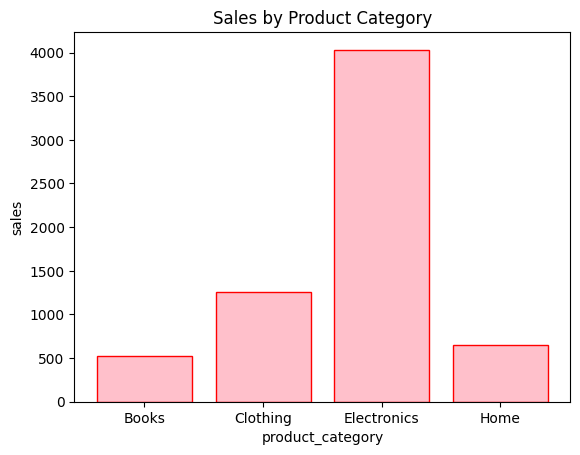

In [76]:
# - Bar chart: Sales by Product Category
sales_by_product_category=sales_data.groupby("product_category")["total_amount"].sum()
sales_by_product_category
plt.bar(sales_by_product_category.index,sales_by_product_category.values,color="pink",edgecolor="red")
plt.xlabel("product_category")
plt.ylabel("sales")
plt.title("Sales by Product Category")
plt.show()

In [77]:
# - Pie chart: Market share by payment method
payment_data.plot.pie(autopct="%1.1f%%")
plt.ylabel("")  # extra label hataane ke liye
plt.title("Market Share by Payment Method")

plt.show()

NameError: name 'payment_data' is not defined

In [ ]:
# - Histogram: Distribution of customer ages
plt.hist(sales_data["customer_age"],bins=15)
plt.xlabel("customer_age")
plt.ylabel("frequency")
plt.show()

In [ ]:
# - Line plot: Sales trend over time
sales_trend=sales_data.groupby(sales_data["purchase_date"].dt.month)["total_amount"].sum()
sales_trend
plt.plot(sales_trend.index,sales_trend.values)
plt.xlabel("month")
plt.ylabel("sales")
plt.title("Sales trend over time")
plt.show()

In [78]:
# - Box plot: Order value by product category

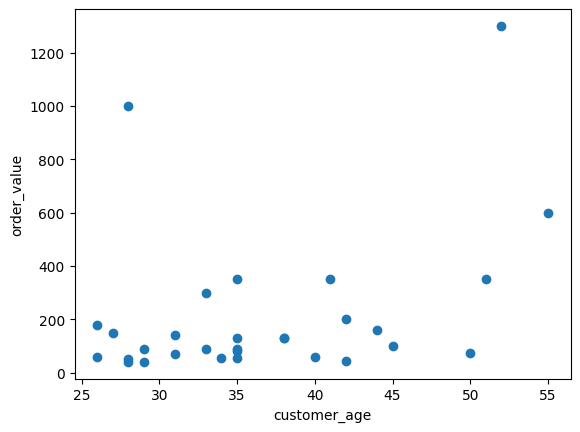

In [79]:
# - Scatter plot: Customer age vs. order value
sales_data["order_value"] = sales_data["quantity"]* sales_data["unit_price"]
plt.scatter(sales_data["customer_age"],sales_data["order_value"])
plt.xlabel("customer_age")
plt.ylabel("order_value")
plt.show()

In [ ]:
# ### **Phase 6: Export Clean Data**

In [80]:
# 18. Save the cleaned and processed dataset to a new CSV file: `cleaned_sales_data.csv`
sales_data.to_csv("cleaned_sales_data.csv",index=False)

In [81]:
# 19. Create a summary report with key statistics and export as a text file
with open("summary_report.txt", "w") as file:
    file.write("Total Transactions: " + str(len(sales_data)) + "\n")
    file.write("Total Revenue: " + str(sales_data["total_amount"].sum()) + "\n")
    file.write("Average Order Value: " + str(sales_data["total_amount"].mean()) + "\n")